Employee attrition is a major challenge for organizations, as high turnover increases recruitment costs and reduces productivity. Understanding the factors that influence employees’ decisions to leave can help organizations take timely preventive actions. This study analyzes employee data from the IBM HR Analytics Employee Attrition & Performance dataset to identify key factors influencing attrition. Exploratory Data Analysis (EDA) is conducted to understand patterns and relationships in the data, followed by machine learning models to predict whether an employee is likely to leave the organization. The findings of this study support data-driven HR decision-making and help improve employee retention strategies.

* XGBClassifier is a machine learning algorithm from the XGBoost library. It uses Gradient Boosting, but in a much faster and more optimized way.
It builds many small decision trees, each new tree fixing the mistakes of the previous ones. This makes it extremely powerful for classification problems like employee attrition prediction.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(df.columns)
df

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [24]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

The dataset contains 1470 employees and 35 features, with no missing values, making it clean and ready for analysis. It includes a balanced mix of 26 numerical and 9 categorical variables covering demographics, job satisfaction, work conditions, performance, and compensation. The attrition variable is highly imbalanced (84% No, 16% Yes), which will need SMOTE or class weighting during modeling. The describe summary shows good variability across numerical columns, allowing meaningful EDA. Overall, the dataset is high quality, ideal for EDA, visual insights, and training a machine-learning model to predict employee attrition.

/tmp/ipython-input-3222670322.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette='viridis')


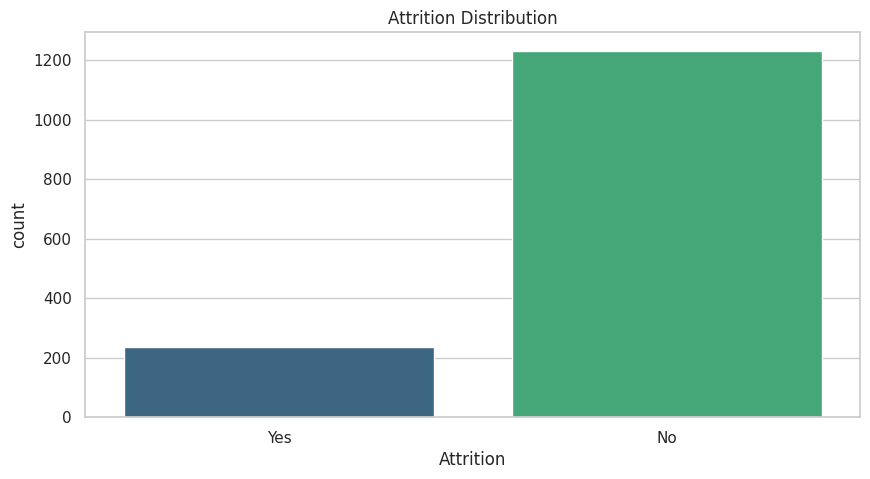

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [25]:
sns.countplot(data=df, x='Attrition', palette='viridis')
plt.title("Attrition Distribution")
plt.show()


attrition_pct = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_pct)

/tmp/ipython-input-403794014.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


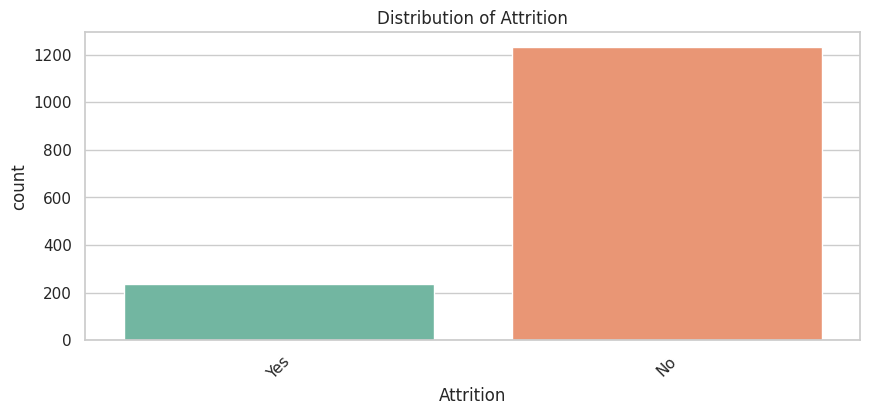

/tmp/ipython-input-403794014.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


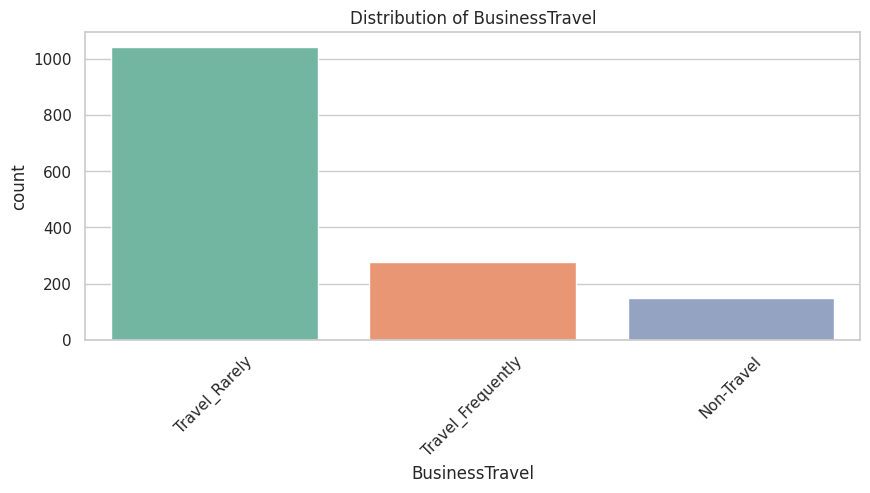

/tmp/ipython-input-403794014.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


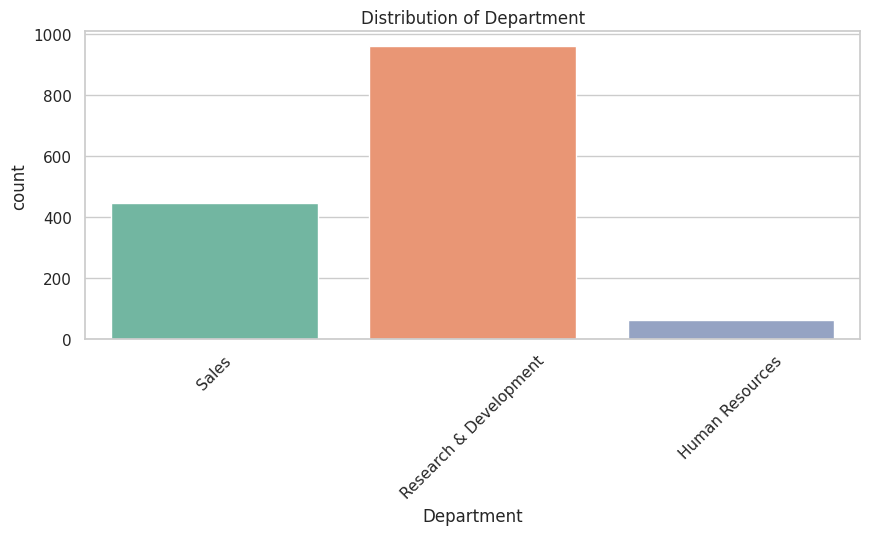

/tmp/ipython-input-403794014.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


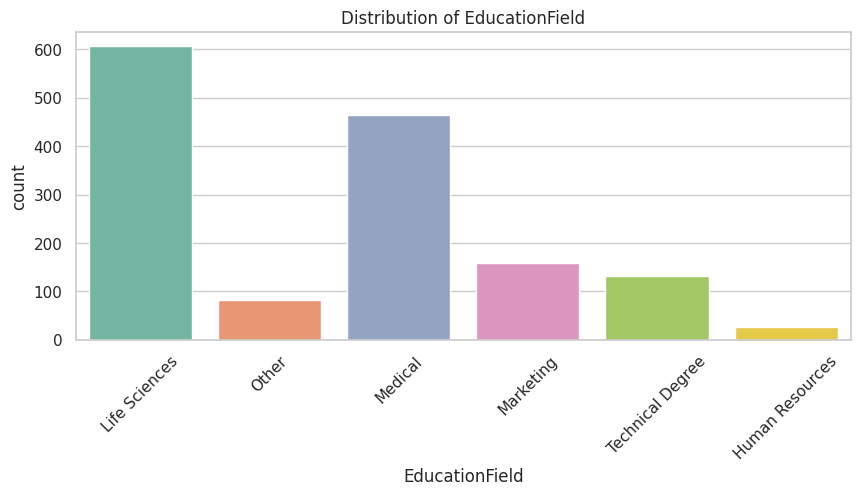

/tmp/ipython-input-403794014.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


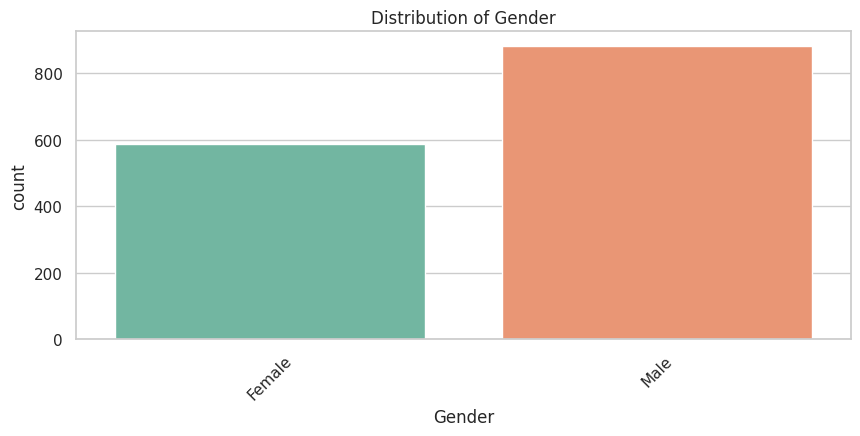

/tmp/ipython-input-403794014.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


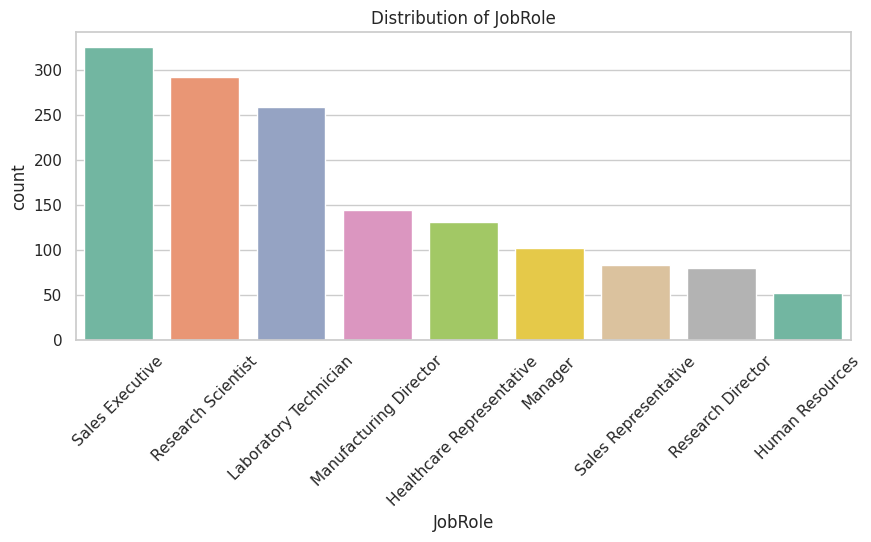

/tmp/ipython-input-403794014.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


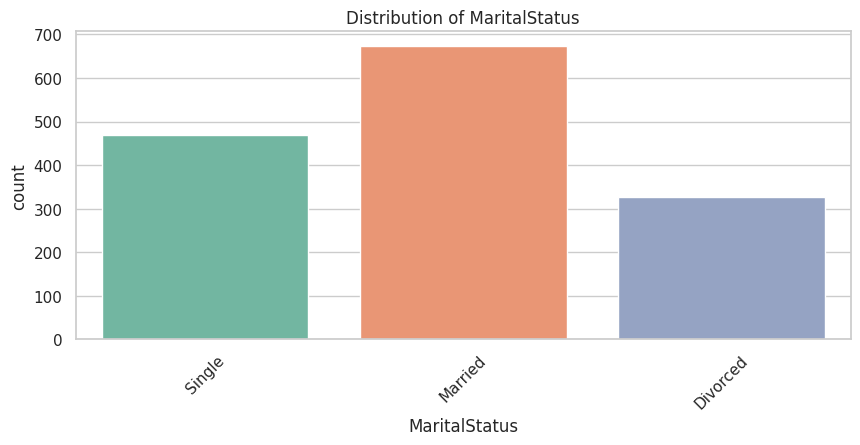

/tmp/ipython-input-403794014.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


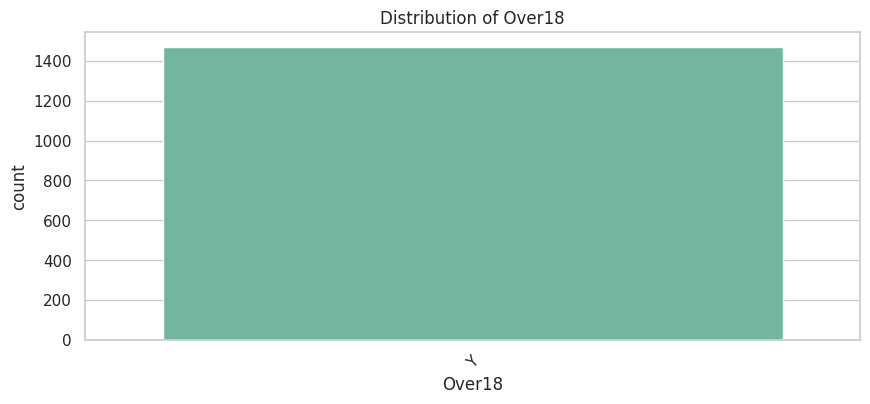

/tmp/ipython-input-403794014.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2')


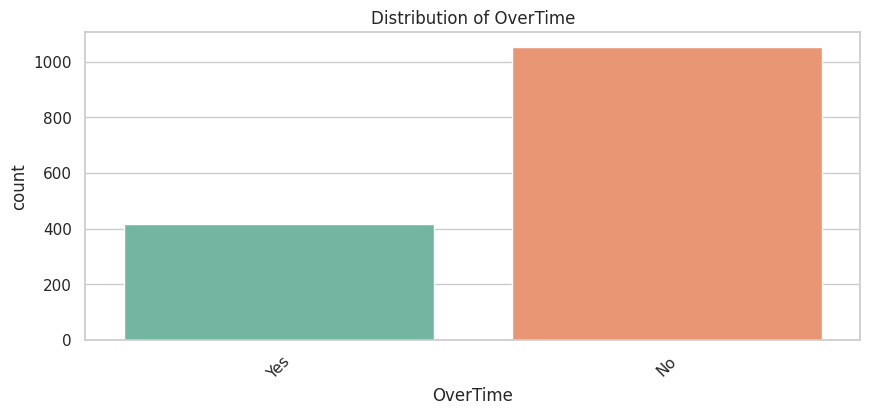

In [26]:

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

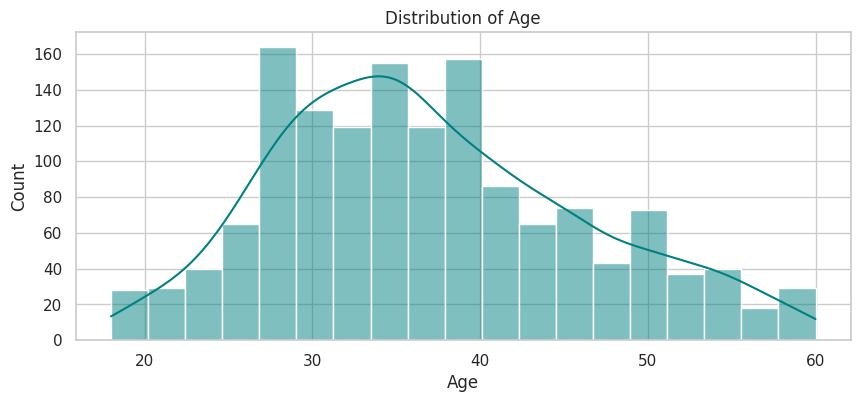

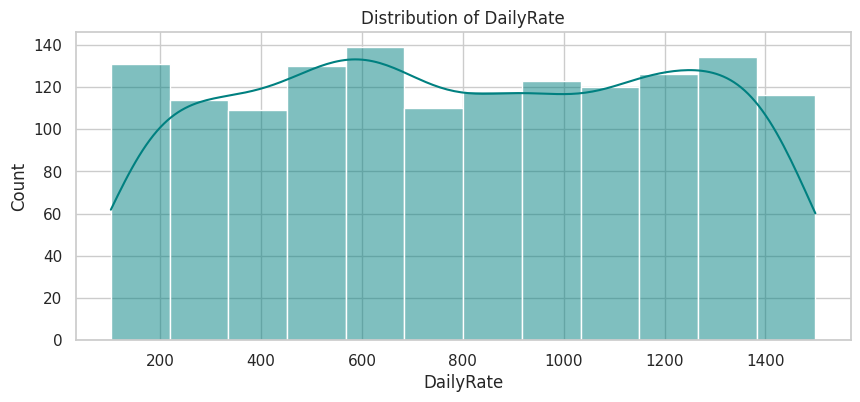

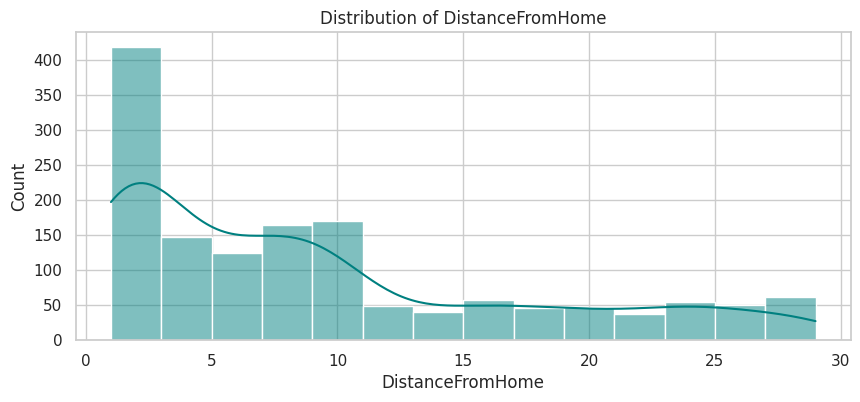

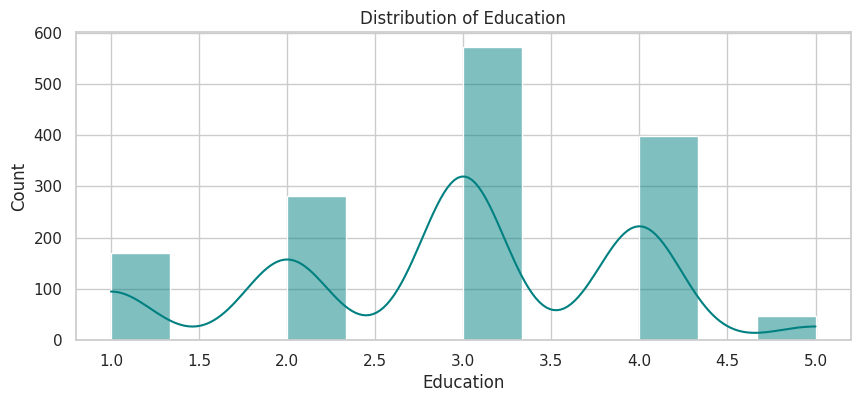

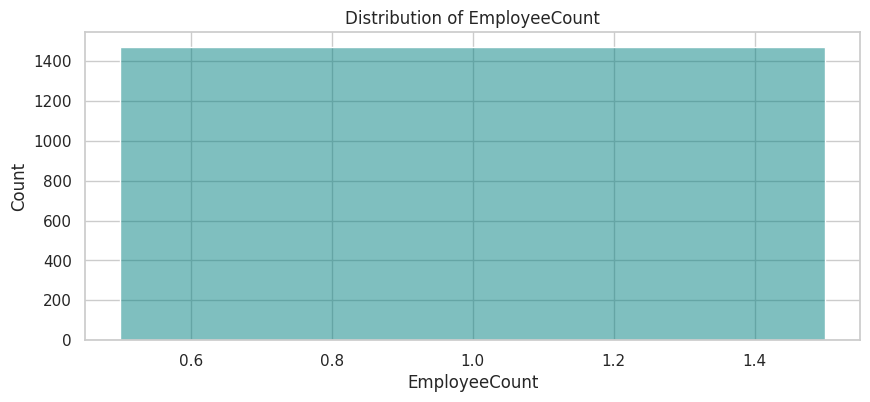

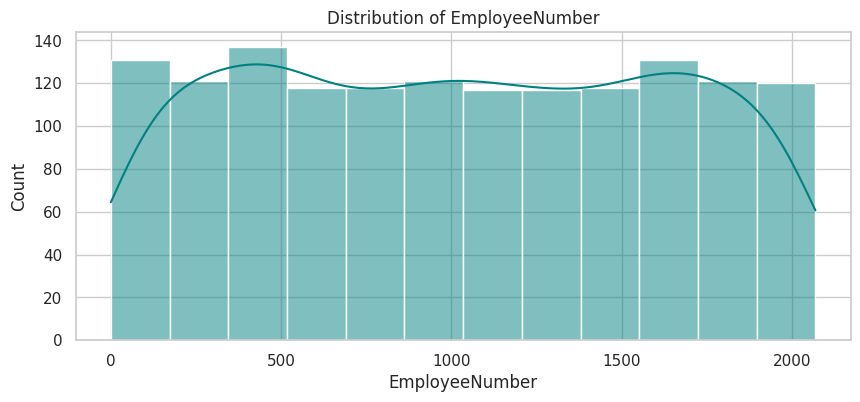

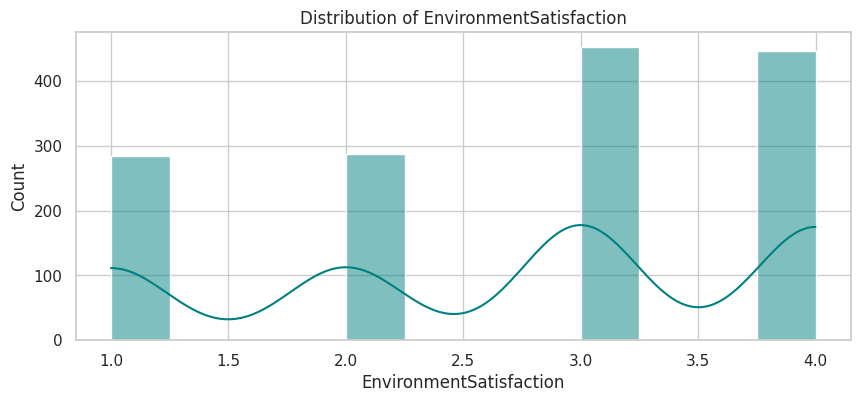

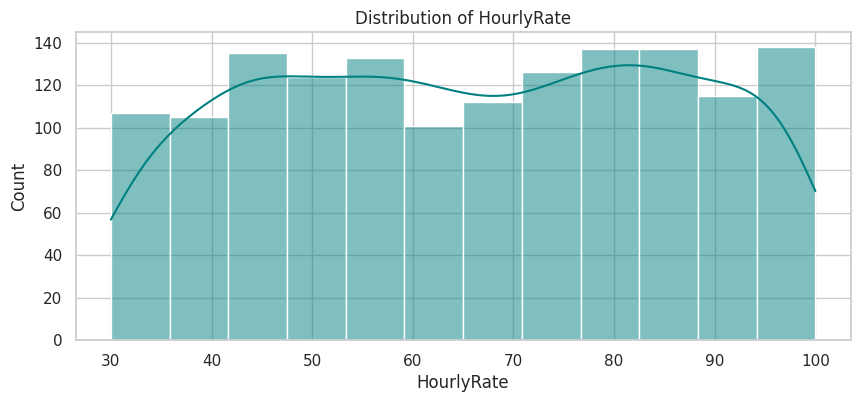

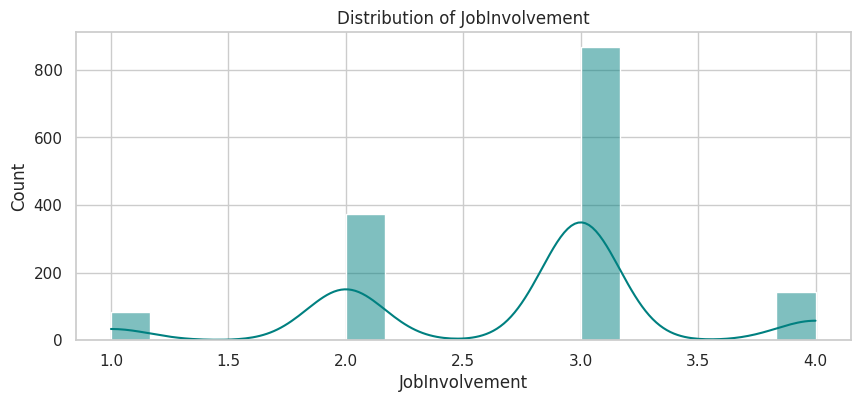

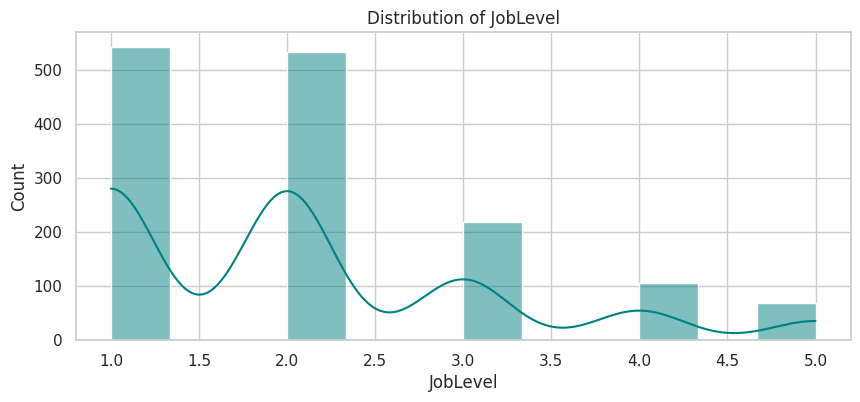

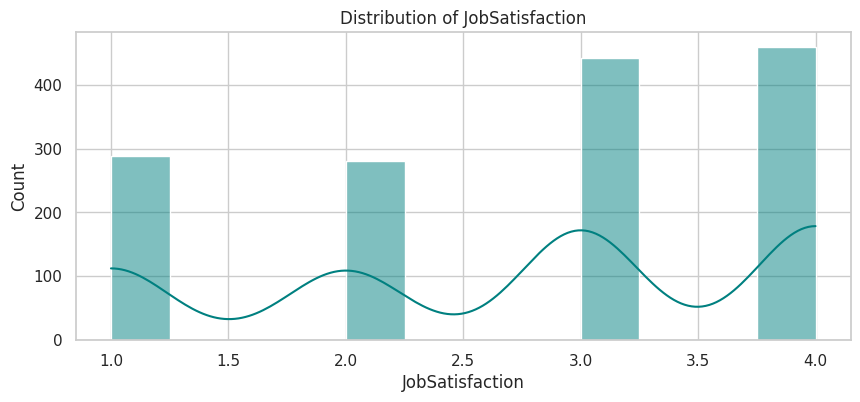

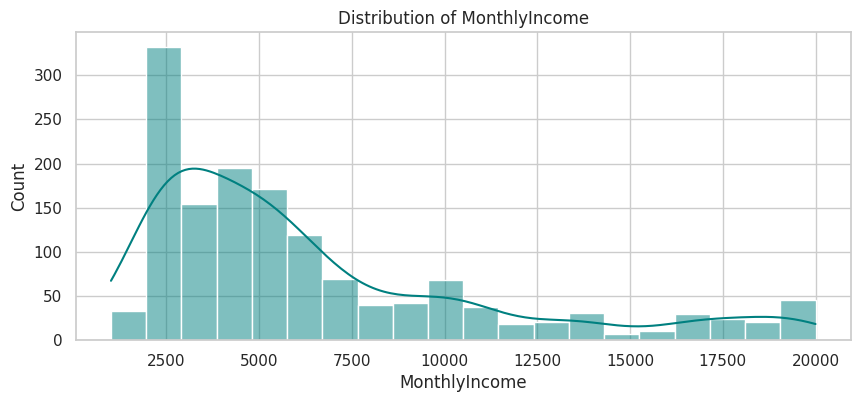

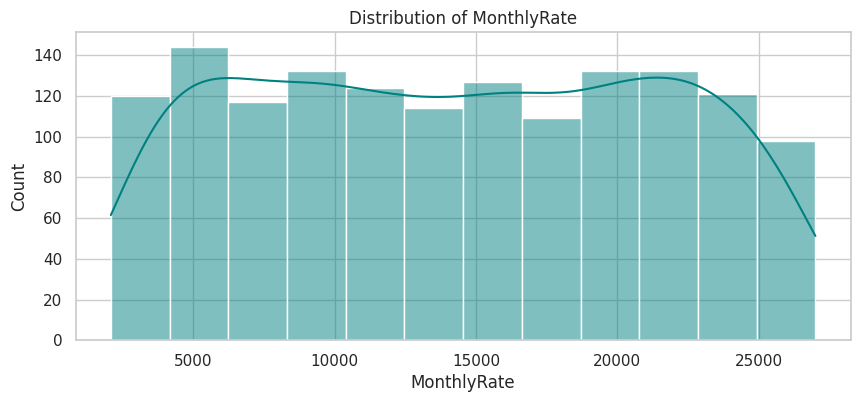

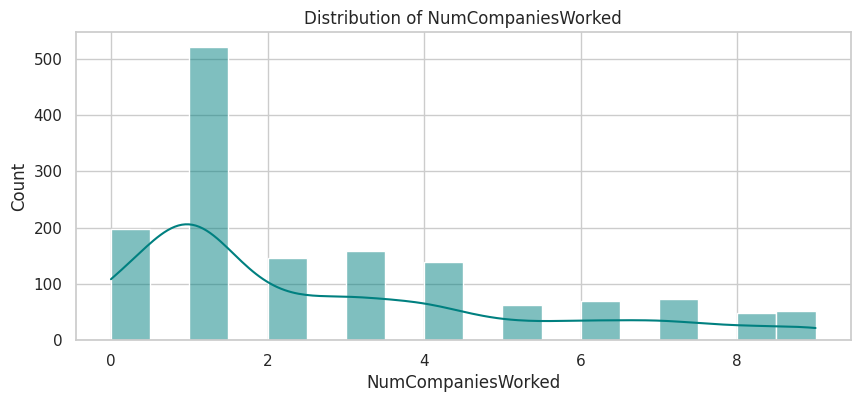

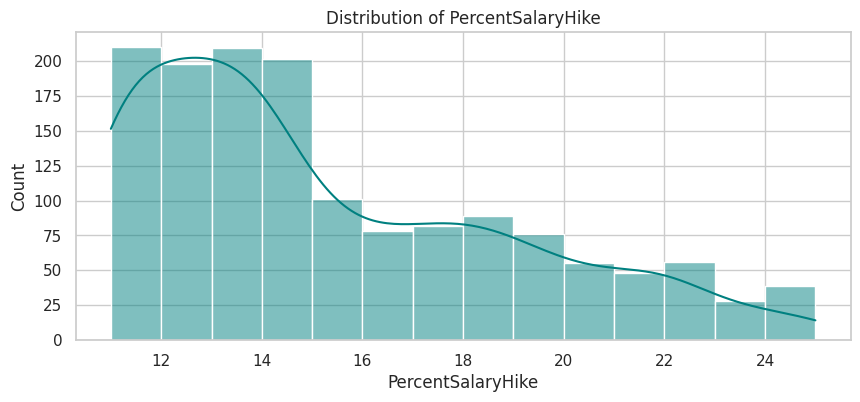

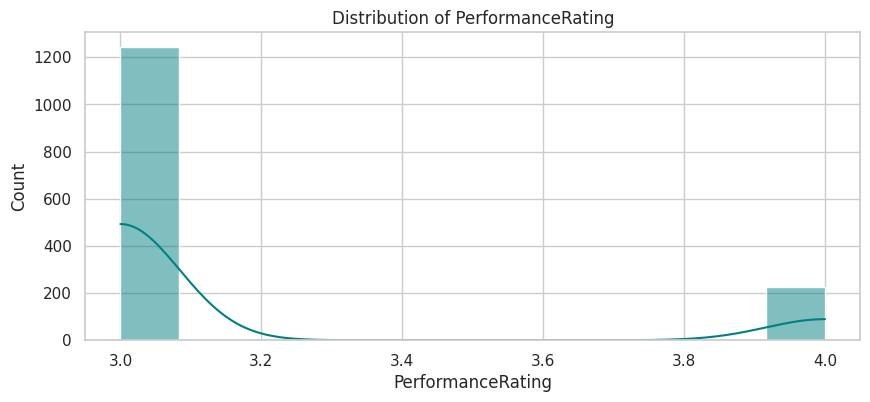

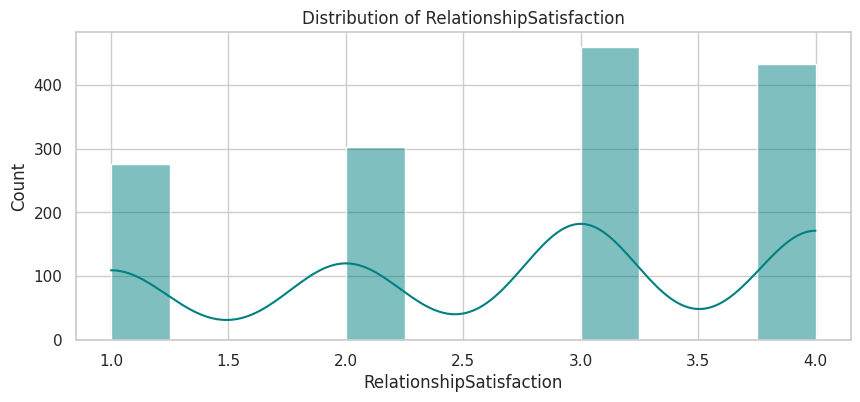

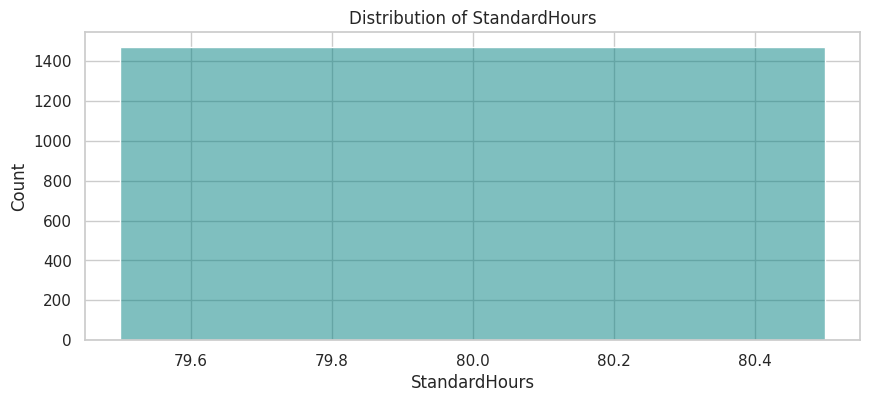

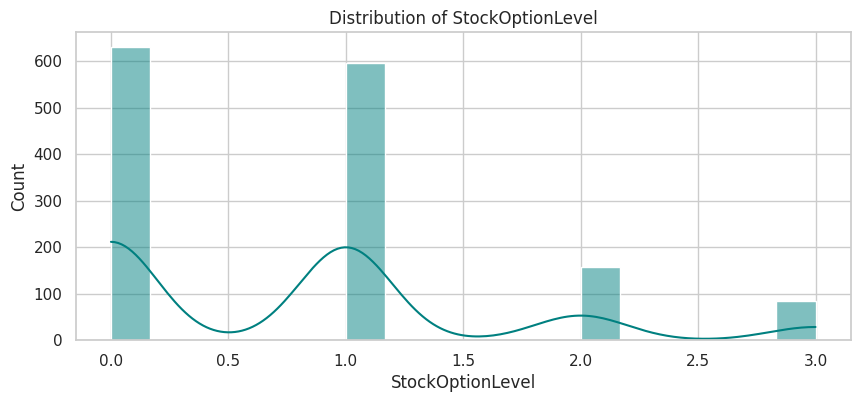

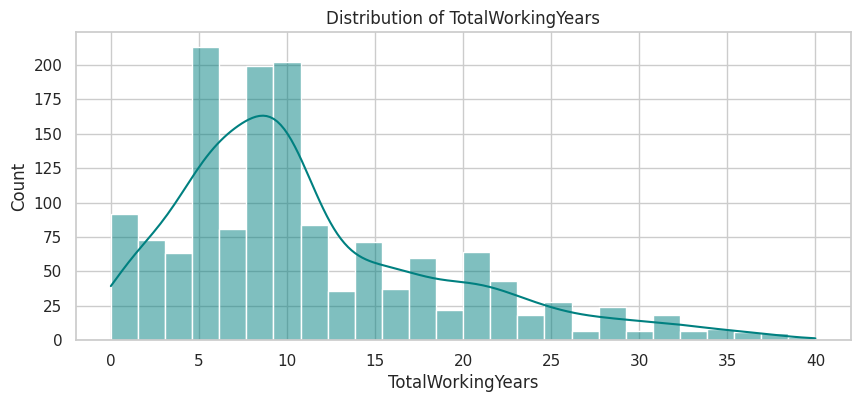

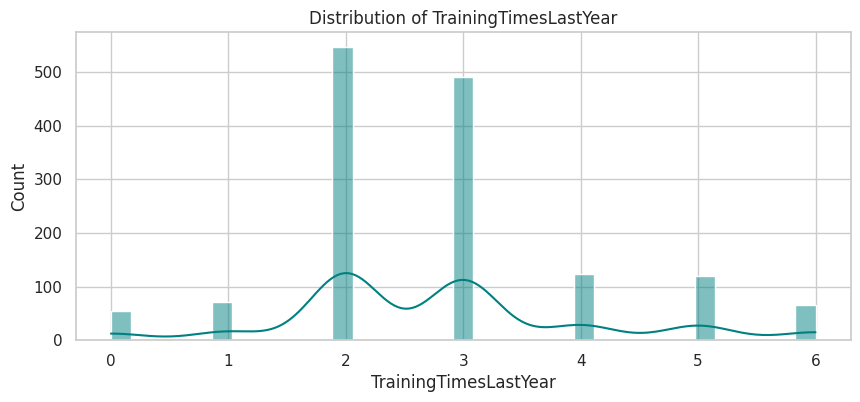

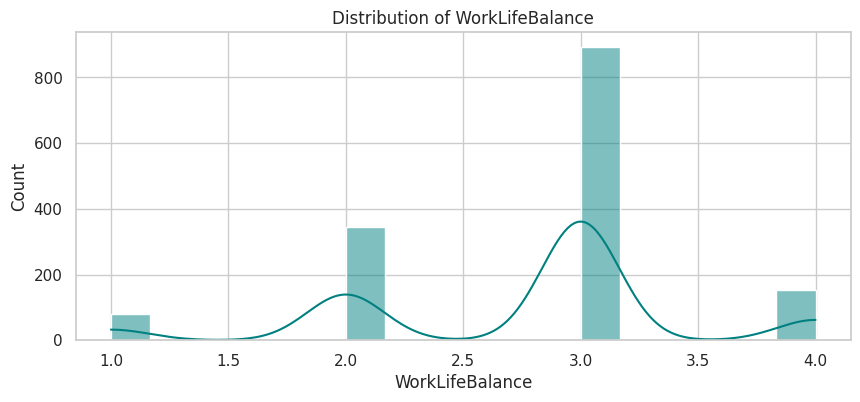

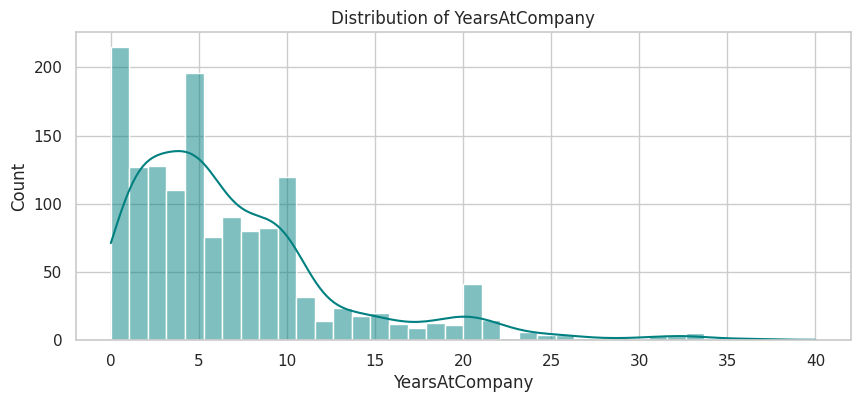

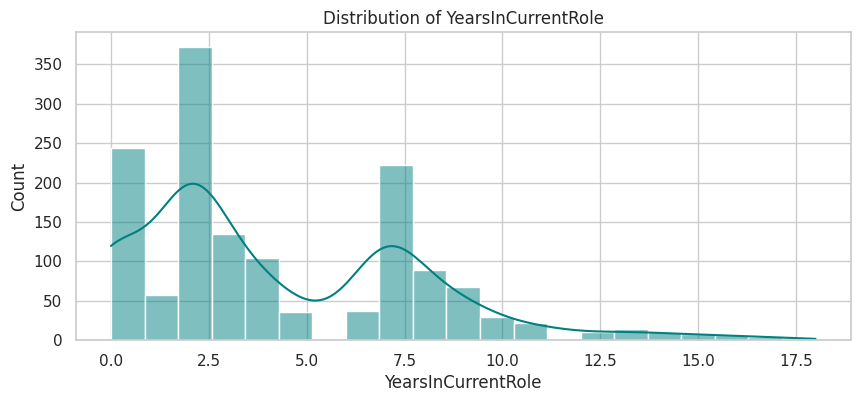

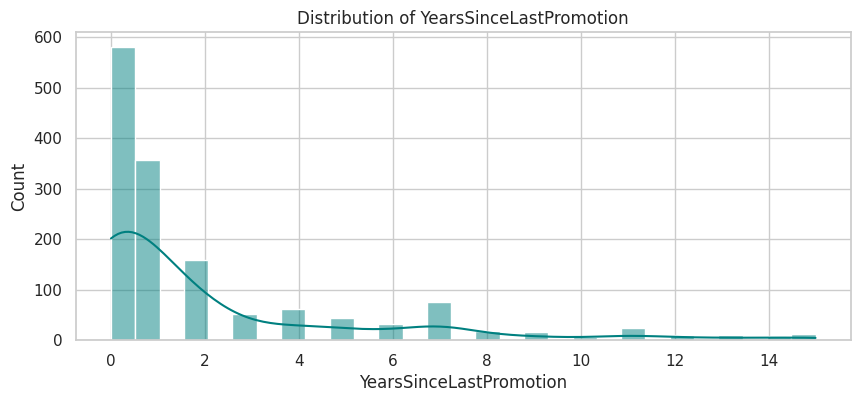

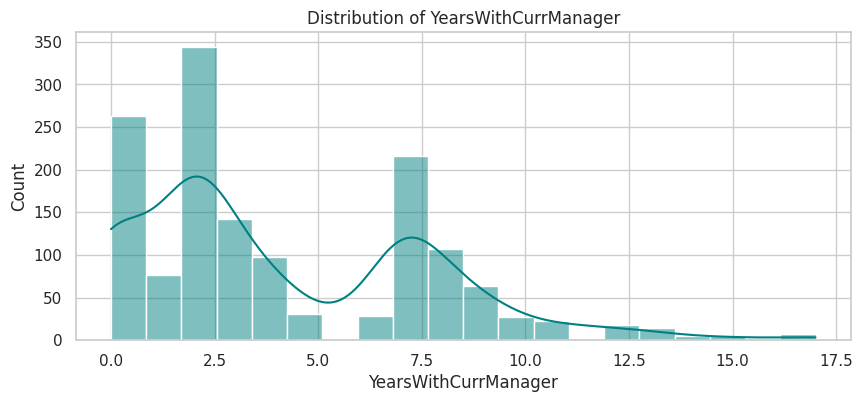

In [27]:

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f"Distribution of {col}")
    plt.show()


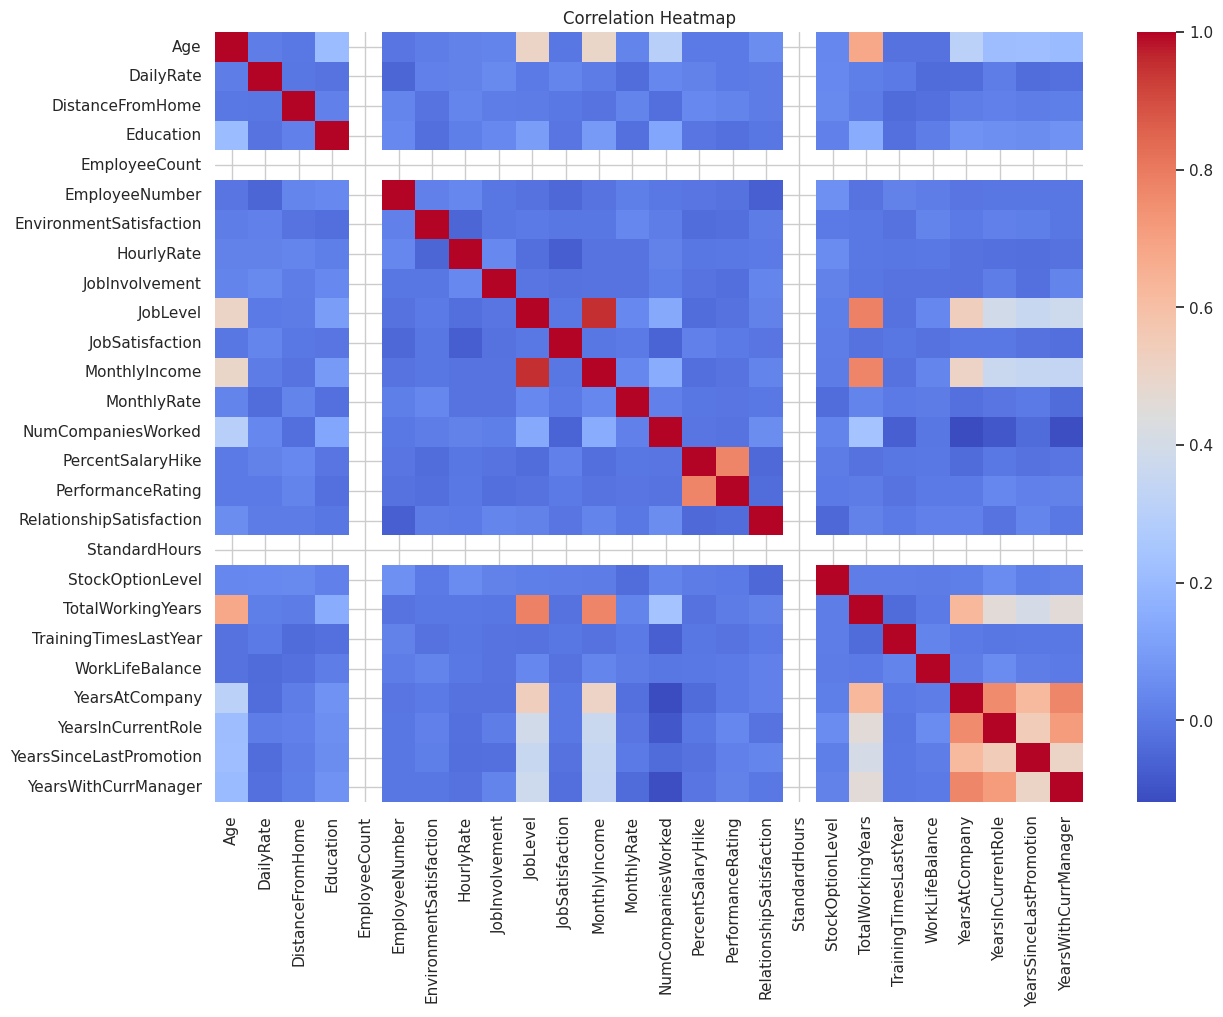

In [28]:
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

/tmp/ipython-input-1037619753.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='cool')


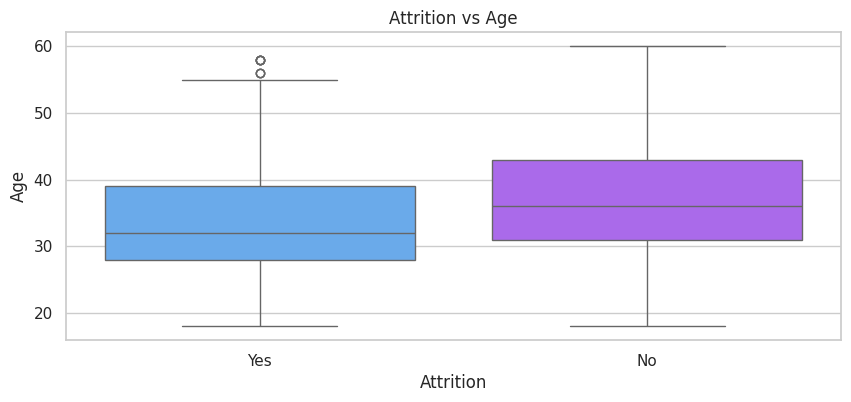

/tmp/ipython-input-1037619753.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='cool')


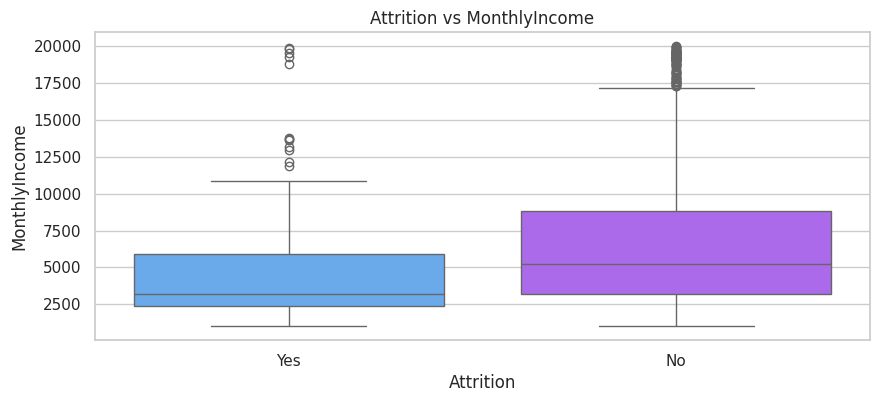

/tmp/ipython-input-1037619753.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='cool')


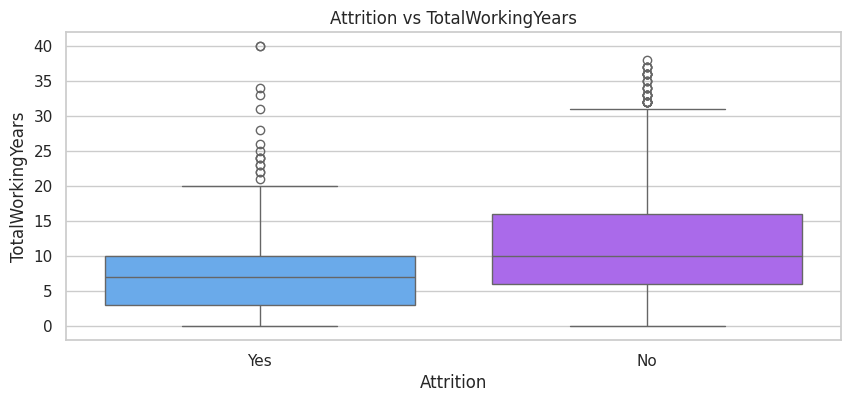

/tmp/ipython-input-1037619753.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='cool')


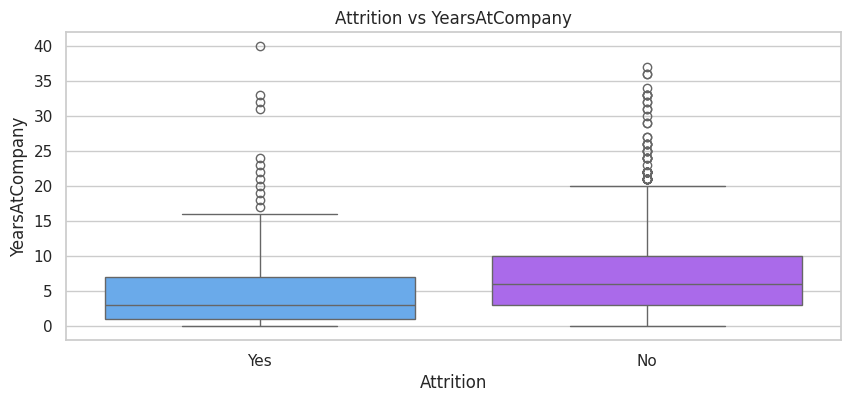

/tmp/ipython-input-1037619753.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='cool')


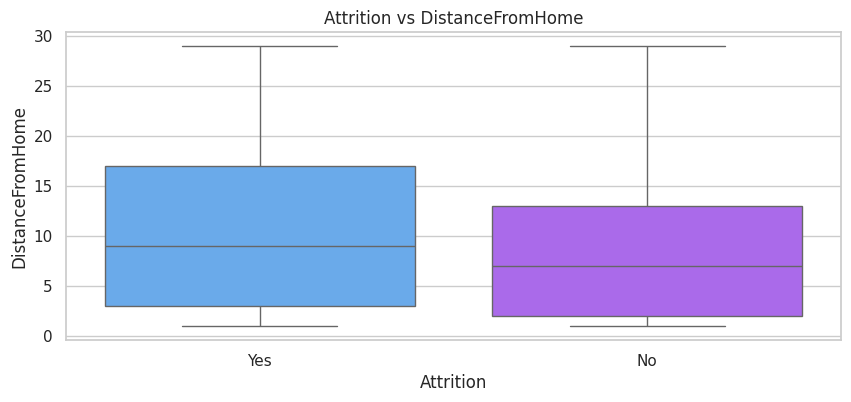

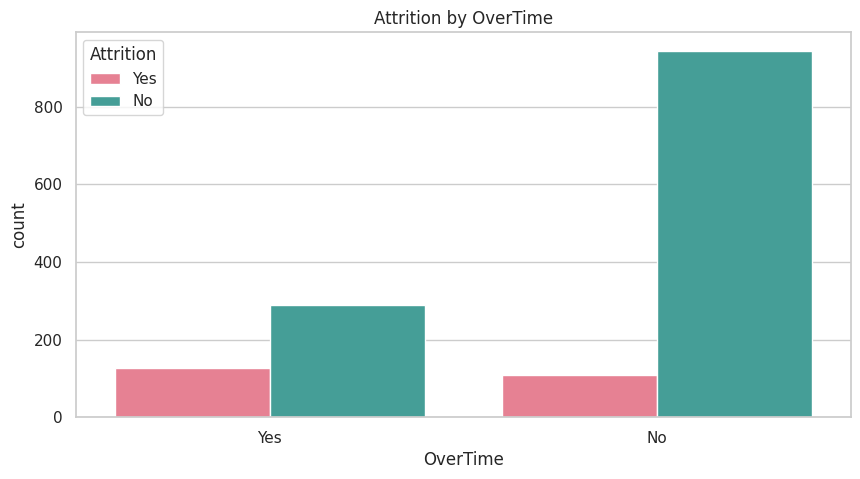

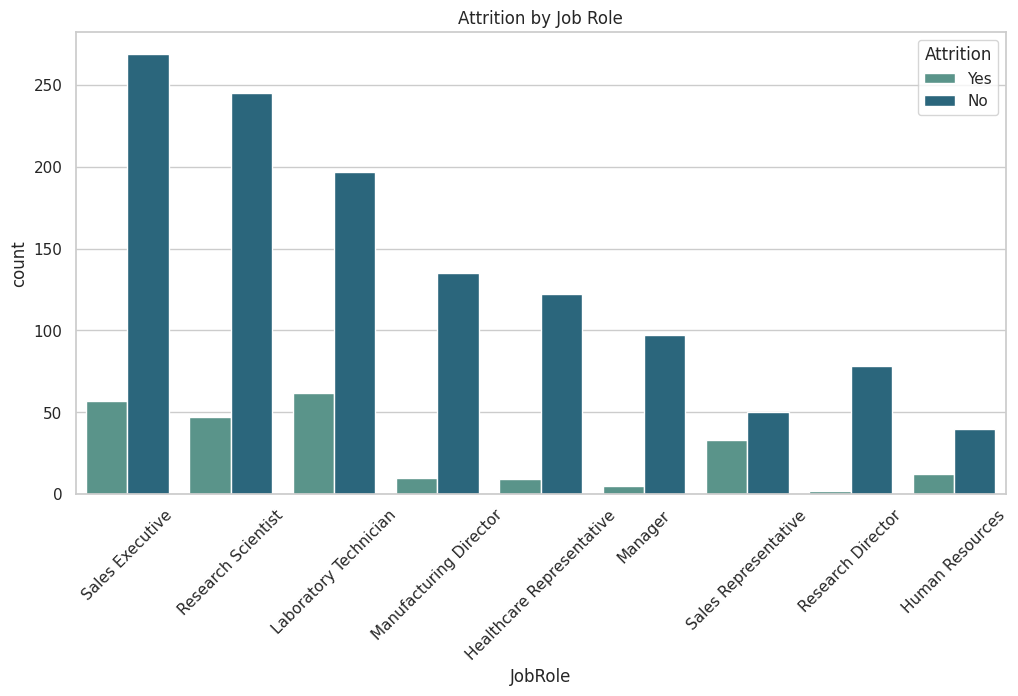

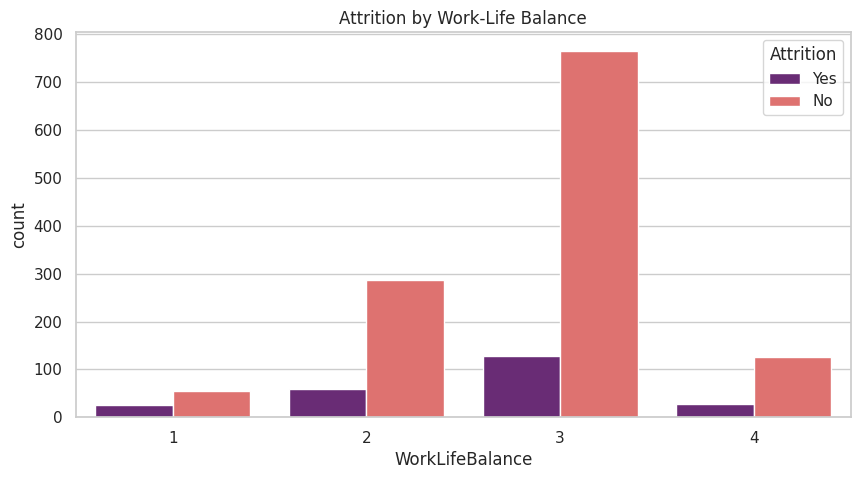

In [29]:
important_numeric = ["Age", "MonthlyIncome", "TotalWorkingYears",
    "YearsAtCompany", "DistanceFromHome"]

for col in important_numeric:
    plt.figure(figsize=(10,4))
    sns.boxplot(data=df, x='Attrition', y=col, palette='cool')
    plt.title(f"Attrition vs {col}")
    plt.show()

sns.countplot(data=df, x='OverTime', hue='Attrition', palette='husl')
plt.title("Attrition by OverTime")
plt.show()


plt.figure(figsize=(12,6))
sns.countplot(data=df, x='JobRole', hue='Attrition', palette='crest')
plt.title("Attrition by Job Role")
plt.xticks(rotation=45)
plt.show()


sns.countplot(data=df, x='WorkLifeBalance', hue='Attrition', palette='magma')
plt.title("Attrition by Work-Life Balance")
plt.show()

In [30]:

drop_cols = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
df.drop(columns=drop_cols, inplace=True)

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop('Attrition', axis=1)
y = df['Attrition']

cat_cols = X.select_dtypes(include='object').columns
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


In [31]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:20:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [32]:
y_pred_xgb = xgb.predict(X_test_scaled)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.826530612244898
Confusion Matrix:
 [[227  20]
 [ 31  16]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90       247
           1       0.44      0.34      0.39        47

    accuracy                           0.83       294
   macro avg       0.66      0.63      0.64       294
weighted avg       0.81      0.83      0.82       294



                    Feature  Importance
18                 OverTime    0.093298
22         StockOptionLevel    0.061264
14            MaritalStatus    0.050263
23        TotalWorkingYears    0.047885
3                Department    0.044533
10           JobInvolvement    0.041871
15            MonthlyIncome    0.041234
13          JobSatisfaction    0.041041
7   EnvironmentSatisfaction    0.037604
17       NumCompaniesWorked    0.036136


/tmp/ipython-input-374583653.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(15), x="Importance", y="Feature", palette='viridis')


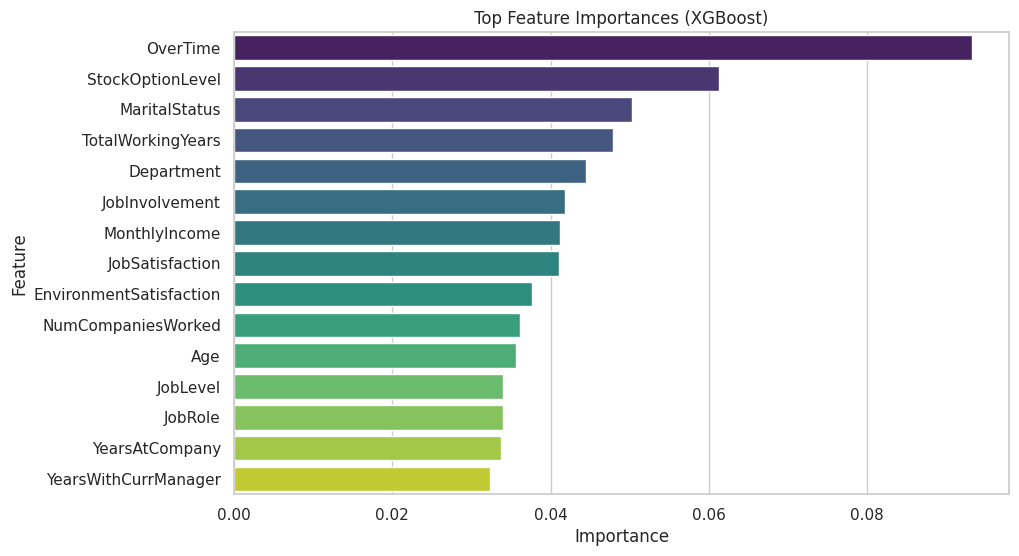

In [13]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df[col].astype(str))

X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)
print(importance.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15), x="Importance", y="Feature", palette='viridis')
plt.title("Top Feature Importances (XGBoost)")
plt.show()

In this mini project, employee data was analyzed to identify key factors influencing attrition using the IBM HR Analytics dataset. After performing EDA to understand distributions and relationships, machine learning models were applied to predict which employees are likely to leave. XGBoost achieved the best performance with 82.7% accuracy, effectively identifying patterns in age, job role, salary, overtime, and satisfaction levels. The findings can help HR teams proactively retain employees and improve workforce stability.

Explanation of Key Factors Influencing Employee Attrition

The XGBoost model was used to identify the most influential factors affecting employee attrition. Feature importance scores represent the relative contribution of each variable in predicting whether an employee is likely to leave the organization.

1. OverTime (9.33%) – Employees working overtime are more likely to leave due to stress and poor work–life balance.

2. StockOptionLevel (6.13%) – Lower long-term financial benefits increase the risk of employee attrition.

3. MaritalStatus (5.03%) – Personal life stability influences an employee’s decision to stay or switch jobs.

4. TotalWorkingYears (4.79%) – Employees with less work experience show higher job mobility and attrition.

5. Department (4.45%) – Attrition varies across departments due to differences in workload and growth opportunities.

6. JobInvolvement (4.19%) – Low engagement with work increases the likelihood of leaving the organization.

7. MonthlyIncome (4.12%) – Lower salary levels motivate employees to seek better-paying opportunities.

8. JobSatisfaction (4.10%) – Dissatisfaction with job roles significantly contributes to employee turnover.

9. EnvironmentSatisfaction (3.76%) – Poor workplace environment increases dissatisfaction and attrition.

10. NumCompaniesWorked (3.61%) – Employees with frequent job changes are more prone to leave again.

In [15]:
# User input
selected_features = ['Age','MonthlyIncome','JobLevel','OverTime','JobSatisfaction','EnvironmentSatisfaction','WorkLifeBalance','TotalWorkingYears']


In [16]:
X = df[selected_features]
y = df['Attrition']

In [17]:
X['OverTime'] = X['OverTime'].map({'Yes': 1, 'No': 0})

/tmp/ipython-input-649382343.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['OverTime'] = X['OverTime'].map({'Yes': 1, 'No': 0})


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [19]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [20]:
import numpy as np

def predict_attrition():
    print("Enter Employee Details:")

    age = int(input("Age: "))
    income = int(input("Monthly Income: "))
    job_level = int(input("Job Level (1–5): "))
    overtime = input("OverTime (Yes/No): ")
    job_sat = int(input("Job Satisfaction (1–4): "))
    env_sat = int(input("Environment Satisfaction (1–4): "))
    work_life = int(input("Work Life Balance (1–4): "))
    total_years = int(input("Total Working Years: "))

    overtime = 1 if overtime.lower() == 'yes' else 0

    user_data = np.array([[age, income, job_level, overtime,
                           job_sat, env_sat, work_life, total_years]])

    user_data_scaled = scaler.transform(user_data)

    prediction = xgb.predict(user_data_scaled)

    if prediction[0] == 1:
        print("Prediction: Employee is likely to leave the company.")
    else:
        print("rediction: Employee is likely to stay in the company.")

predict_attrition()

Enter Employee Details:
Age: 41
Monthly Income: 30000
Job Level (1–5): 2
OverTime (Yes/No): Yes
Job Satisfaction (1–4): 2
Environment Satisfaction (1–4): 2
Work Life Balance (1–4): 1
Total Working Years: 9
Prediction: Employee is likely to leave the company.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
import numpy as np

def predict_attrition():
    print("Enter Employee Details:")

    age = int(input("Age: "))
    income = int(input("Monthly Income: "))
    job_level = int(input("Job Level (1–5): "))
    overtime = input("OverTime (Yes/No): ")
    job_sat = int(input("Job Satisfaction (1–4): "))
    env_sat = int(input("Environment Satisfaction (1–4): "))
    work_life = int(input("Work Life Balance (1–4): "))
    total_years = int(input("Total Working Years: "))

    overtime = 1 if overtime.lower() == 'yes' else 0

    user_data = np.array([[age, income, job_level, overtime,
                           job_sat, env_sat, work_life, total_years]])

    user_data_scaled = scaler.transform(user_data)

    prediction = xgb.predict(user_data_scaled)

    if prediction[0] == 1:
        print("Prediction: Employee is likely to leave the company.")
    else:
        print("rediction: Employee is likely to stay in the company.")

predict_attrition()

Enter Employee Details:
Age: 35
Monthly Income: 50000
Job Level (1–5): 4
OverTime (Yes/No): No
Job Satisfaction (1–4): 3
Environment Satisfaction (1–4): 3
Work Life Balance (1–4): 3
Total Working Years: 7
rediction: Employee is likely to stay in the company.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


This user input module allows real-time prediction of employee attrition by taking key employee details (age, income, overtime, satisfaction, experience, etc.) and passing them to the trained machine learning model.
It demonstrates how the model can be practically used by HR teams to assess whether an employee is likely to leave, instead of only analyzing historical data.
This makes the project applied and decision-oriented, showing how predictive analytics can support preventive HR actions such as improving work-life balance, adjusting compensation, or reducing overtime.